# Normalizing Flow — Unsupervised Anomaly Detection of Emerging Jets

**Task 2 — Normalising Flows**

## Strategia

Un **Normalizing Flow** è un modello generativo che impara la distribuzione $p(x)$ tramite una
sequenza di trasformazioni invertibili da uno spazio latente gaussiano allo spazio dei dati.

$$x = f_K \circ \cdots \circ f_1(z), \quad z \sim \mathcal{N}(0, I)$$

Il log-likelihood esatto si calcola con il **change-of-variables theorem**:

$$\log p(x) = \log p_z(z) - \sum_{k=1}^K \log \left| \det J_{f_k} \right|$$

### Pipeline di anomaly detection
1. **Training** esclusivamente su jet QCD (background standard): il flow impara $p_{\text{QCD}}(x)$.
2. **Anomaly score** = $-\log p(x)$: jet con bassa likelihood sono anomali (candidati EJ).
3. **Valutazione** su sample misto QCD + EJ: ROC curve, AUC, distribuzioni degli score.

### Architettura: RealNVP
Usiamo **RealNVP** (Dinh et al., 2017) con *affine coupling layers*:
- Ogni layer divide le dimensioni in due metà: $x = (x_a, x_b)$
- $x_b' = x_b \odot \exp(s(x_a)) + t(x_a)$ — solo $x_a$ entra nelle reti $s, t$
- Il Jacobiano è triangolare → $\log|\det J| = \sum \log|\exp(s(x_a))| = \sum s(x_a)$
- Vantaggi: forward e inverse veloci, Jacobiano esatto e cheap

### Input
Usiamo la rappresentazione **embedding fisso** (86-dim) prodotta dal preprocessing:
- 5 statistiche (mean, std, p25, p75, max) × 15 feature di traccia = 75
- 1 feature scalare (n_tracce valide) = 1
- 10 feature di jet (pt, eta, mass, ...) = 10
- **Totale: 86 dimensioni**, già normalizzate (mean≈0, std≈1 sul training set QCD)

## 0. Setup

In [1]:
import subprocess
# Installa normflows se non presente (opzionale, usiamo implementazione custom)
# subprocess.run(['pip', 'install', 'normflows'], check=False)

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Riproducibilità
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.11.0+cpu


## 1. Configurazione

In [2]:
from pathlib import Path

# ── Percorsi ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
EMBED_PATH = BASE_DIR / 'outputs' / 'embeddings_preprocessed.npz'
OUT_DIR    = Path(r'C:\Users\delco\Desktop\Universita\Ad_M') / 'nf_results'
OUT_DIR.mkdir(exist_ok=True)

assert EMBED_PATH.exists(), f'File non trovato: {EMBED_PATH}'
print(f'Embedding file: {EMBED_PATH}  ({EMBED_PATH.stat().st_size/1e6:.1f} MB)')

# ── Iperparametri ─────────────────────────────────────────────────────────────
INPUT_DIM      = 86         # dimensione embedding
N_COUPLING     = 8          # numero di coupling layer RealNVP
HIDDEN_DIM     = 256        # neuroni nei layer s e t
N_HIDDEN       = 2          # layer nascosti nelle reti s, t

BATCH_SIZE     = 512
LR             = 3e-4
N_EPOCHS       = 50
PATIENCE       = 10         # early stopping
CLIP_GRAD      = 5.0        # gradient clipping

print(f'Input dim: {INPUT_DIM}')
print(f'Coupling layers: {N_COUPLING}')
print(f'Hidden dim: {HIDDEN_DIM}')


Embedding file: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\embeddings_preprocessed.npz  (35.2 MB)
Input dim: 86
Coupling layers: 8
Hidden dim: 256


## 2. Caricamento dati

In [3]:
data = np.load(EMBED_PATH)

X_train = data['X_train'].astype(np.float32)   # (N_train, 86) — solo QCD
y_train = data['y_train'].astype(np.int64)      # (N_train,)    — tutti 0
X_val   = data['X_val'].astype(np.float32)      # (N_val,   86) — QCD + EJ
y_val   = data['y_val'].astype(np.int64)        # (N_val,)
X_test  = data['X_test'].astype(np.float32)     # (N_test,  86) — QCD + EJ
y_test  = data['y_test'].astype(np.int64)       # (N_test,)

print(f'Training set (QCD only): {X_train.shape[0]:,} jets')
print(f'Val set:                 {X_val.shape[0]:,}  jets  '
      f'(QCD: {(y_val==0).sum():,}, EJ: {(y_val==1).sum():,})')
print(f'Test set:                {X_test.shape[0]:,}  jets  '
      f'(QCD: {(y_test==0).sum():,}, EJ: {(y_test==1).sum():,})')
print(f'\nRanges (train): min={X_train.min():.3f}, max={X_train.max():.3f}')
print(f'NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}')

Training set (QCD only): 40,000 jets
Val set:                 30,000  jets  (QCD: 5,000, EJ: 25,000)
Test set:                30,000  jets  (QCD: 5,000, EJ: 25,000)

Ranges (train): min=-32.812, max=78.598
NaN: 0, Inf: 0


## 2b. Diagnostica: AUC per-feature

Prima di addestrare il modello, identifichiamo le feature che da sole discriminano quasi perfettamente QCD da EJ.
Queste vanno **escluse** perché rendono il problema banale e non rappresentano un risultato ML genuino.

### Criteri di esclusione
- ****: calcolata associando tracce a vertici displaced → richiede la ricostruzione del vertice displaced, non è una feature "raw". Su QCD è esattamente 0, su EJ ha valore medio ~1.2. **Discriminatore perfetto (AUC≈0.998)**.
- Le feature di traccia ad alto AUC (, , ) sono osservabili fisicamente legittimi e **vanno tenute**: sono esattamente ciò che l'analisi vuole sfruttare.


In [4]:
# ── Mappa dei nomi delle 86 dimensioni dell'embedding ──────────────────────
TRACK_FEATURES = [
    "pt_log1p", "d0_log1p", "z0RelativeToBeamspot", "deta", "dphi",
    "dr", "ptfrac", "qOverP", "chiSquared", "radiusOfFirstHit",
    "IP3D_signed_d0_significance", "IP3D_signed_z0_significance",
    "numberOfInnermostPixelLayerHits", "numberOfPixelHits", "numberOfSCTHits",
]
JET_FEATURES = [
    "pt", "eta", "mass", "energy", "displacedPtFraction",
    "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",
    "Split12_clusterSoftDrop", "timing_clusterSoftDrop", "nPrimaryVertices",
]
STATS = ["mean", "std", "p25", "p75", "max"]
EMB_NAMES = ([f"{s}_{f}" for s in STATS for f in TRACK_FEATURES]
             + ["n_valid"]
             + JET_FEATURES)  # total: 75 + 1 + 10 = 86

assert len(EMB_NAMES) == 86

# ── AUC per-feature sul test set ────────────────────────────────────────────
from sklearn.metrics import roc_auc_score

aucs = []
for i, name in enumerate(EMB_NAMES):
    a = roc_auc_score(y_test, X_test[:, i])
    aucs.append((i, name, a))

aucs_sorted = sorted(aucs, key=lambda x: abs(x[2] - 0.5), reverse=True)

print(f"{"dim":>5s}  {"AUC":>6s}  feature")
print("-" * 55)
for dim, name, a in aucs_sorted[:20]:
    flag = "  ← ESCLUDI" if name == "displacedPtFraction" else ""
    print(f"  {dim:3d}    {a:.4f}  {name}{flag}")


  dim     AUC  feature
-------------------------------------------------------
   80    0.9978  displacedPtFraction  ← ESCLUDI
   35    0.8579  p25_dr
   12    0.1493  mean_numberOfInnermostPixelLayerHits
   13    0.1654  mean_numberOfPixelHits
   20    0.1769  std_dr
    9    0.8218  mean_radiusOfFirstHit
   46    0.8199  p75_d0_log1p
   54    0.8173  p75_radiusOfFirstHit
    5    0.8172  mean_dr
   15    0.1858  std_pt_log1p
   31    0.1888  p25_d0_log1p
   43    0.2091  p25_numberOfPixelHits
   24    0.7692  std_radiusOfFirstHit
   39    0.7691  p25_radiusOfFirstHit
   83    0.7397  Split12_clusterSoftDrop
   60    0.2609  max_pt_log1p
   29    0.7232  std_numberOfSCTHits
    0    0.2808  mean_pt_log1p
   19    0.7145  std_dphi
   79    0.2913  energy


## 2c. Feature set pulito

Rimuoviamo `displacedPtFraction` (dim 80) dall'embedding.

**Perché solo questa?** Tutte le altre feature ad alto AUC (`radiusOfFirstHit`, `d0_log1p`, `dr`) sono osservabili di traccia raw — esattamente quelli che il progetto mira a sfruttare.

`displacedPtFraction` è calcolata **dopo** la ricostruzione di vertici displaced: su QCD vale sempre 0, su EJ vale ~1.2. Includerla equivale a usare il label come input.


In [5]:
# ── Indici da rimuovere ──────────────────────────────────────────────────────
EXCLUDE_FEATURES = ["displacedPtFraction"]
DROP_DIMS = [EMB_NAMES.index(f) for f in EXCLUDE_FEATURES]
KEEP_DIMS = [i for i in range(86) if i not in DROP_DIMS]

print(f"Dimensioni rimosse: {DROP_DIMS}  ({EXCLUDE_FEATURES})")
print(f"Dimensioni rimaste: {len(KEEP_DIMS)} / 86")

# ── Filtra tutti i set ───────────────────────────────────────────────────────
X_train = X_train[:, KEEP_DIMS]
X_val   = X_val[:,   KEEP_DIMS]
X_test  = X_test[:,  KEEP_DIMS]

# Aggiorna dimensione input
INPUT_DIM = X_train.shape[1]
print(f"Nuova INPUT_DIM: {INPUT_DIM}")

# Aggiorna i tensori
X_train_t = torch.from_numpy(X_train).to(device)
X_val_t   = torch.from_numpy(X_val).to(device)
X_test_t  = torch.from_numpy(X_test).to(device)

ds_train       = TensorDataset(X_train_t)
X_val_qcd_t    = X_val_t[torch.from_numpy(y_val) == 0]
ds_val_qcd     = TensorDataset(X_val_qcd_t)
loader_train   = DataLoader(ds_train,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val_qcd = DataLoader(ds_val_qcd, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"DataLoader pronti. Batch per epoca: {len(loader_train)}")


Dimensioni rimosse: [80]  (['displacedPtFraction'])
Dimensioni rimaste: 85 / 86
Nuova INPUT_DIM: 85
DataLoader pronti. Batch per epoca: 79


## 3. Modello RealNVP

### 3.1 Rete residua per le funzioni s e t

Ogni coupling layer usa due reti neurali (`scale_net` e `translate_net`).
Usiamo un singolo MLP con output diviso in (s, t) per efficienza.

In [6]:
class MLP(nn.Module):
    """MLP con BatchNorm e LeakyReLU per le reti s e t del coupling layer."""

    def __init__(self, in_dim: int, out_dim: int, hidden_dim: int, n_hidden: int):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * n_hidden + [out_dim]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:       # non dopo l'ultimo layer
                layers.append(nn.LeakyReLU(0.1))
                layers.append(nn.BatchNorm1d(dims[i+1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### 3.2 Affine Coupling Layer

Dati $x = (x_a, x_b)$ con $x_a \in \mathbb{R}^{d_1}$, $x_b \in \mathbb{R}^{d_2}$:

**Forward (x → z):**
$$s, t = \text{MLP}(x_a) \qquad z_a = x_a \qquad z_b = x_b \odot \exp(s) + t$$
$$\log|\det J| = \sum s$$

**Inverse (z → x):**
$$x_a = z_a \qquad x_b = (z_b - t) \odot \exp(-s)$$

In [7]:
class AffineCouplingLayer(nn.Module):
    """
    RealNVP affine coupling layer.
    `mask` è un vettore binario (dim,): 1 = passthrough (x_a), 0 = trasformato (x_b).
    """

    def __init__(self, dim: int, mask: torch.Tensor,
                 hidden_dim: int, n_hidden: int):
        super().__init__()
        self.register_buffer('mask', mask.float())
        d_in = int(mask.sum().item())           # dim di x_a
        d_out = dim - d_in                      # dim di x_b

        # Rete unica che produce (s, t) concatenati
        self.net = MLP(d_in, 2 * d_out, hidden_dim, n_hidden)

        # Scale tanh per stabilità numerica di s
        self.log_scale_factor = nn.Parameter(torch.zeros(d_out))

        # Indici fissi delle due metà
        self.register_buffer('idx_a', (mask == 1).nonzero(as_tuple=True)[0])
        self.register_buffer('idx_b', (mask == 0).nonzero(as_tuple=True)[0])

    def forward(self, x):
        """Forward pass: x → z, restituisce (z, log_det_J)."""
        x_a = x[:, self.idx_a]      # (B, d_in)
        x_b = x[:, self.idx_b]      # (B, d_out)

        st  = self.net(x_a)                         # (B, 2*d_out)
        s   = torch.tanh(st[:, :x_b.shape[1]]) * torch.exp(self.log_scale_factor)
        t   = st[:, x_b.shape[1]:]

        z_b = x_b * torch.exp(s) + t
        log_det = s.sum(dim=1)          # (B,)

        z = x.clone()
        z[:, self.idx_b] = z_b
        return z, log_det

    def inverse(self, z):
        """Inverse pass: z → x."""
        z_a = z[:, self.idx_a]
        z_b = z[:, self.idx_b]

        st  = self.net(z_a)
        s   = torch.tanh(st[:, :z_b.shape[1]]) * torch.exp(self.log_scale_factor)
        t   = st[:, z_b.shape[1]:]

        x_b = (z_b - t) * torch.exp(-s)

        x = z.clone()
        x[:, self.idx_b] = x_b
        return x

### 3.3 ActNorm

Layer di normalizzazione per attivazione (inizializzato con i dati del primo batch), utile per stabilizzare il training nelle prime epoche.

In [8]:
class ActNorm(nn.Module):
    """
    Activation normalization (Kingma & Dhariwal, Glow 2018).
    Scala e shift per-feature inizializzati sul primo batch.
    """

    def __init__(self, dim: int):
        super().__init__()
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias      = nn.Parameter(torch.zeros(dim))
        self.initialized = False

    @torch.no_grad()
    def _initialize(self, x):
        mean = x.mean(0)
        std  = x.std(0).clamp(min=1e-6)
        self.bias.data      = -mean
        self.log_scale.data = -torch.log(std)
        self.initialized    = True

    def forward(self, x):
        if not self.initialized:
            self._initialize(x)
        z       = (x + self.bias) * torch.exp(self.log_scale)
        log_det = self.log_scale.sum().expand(x.shape[0])   # (B,)
        return z, log_det

    def inverse(self, z):
        return z * torch.exp(-self.log_scale) - self.bias

### 3.4 RealNVP completo

Stacking di $K$ coupling layers con maschere alternate (checkerboard), preceduti da ActNorm.
La distribuzione base è $\mathcal{N}(0, I_{86})$.

In [9]:
class RealNVP(nn.Module):
    """
    RealNVP con N coupling layers e ActNorm.
    Supporta calcolo del log-likelihood esatto.
    """

    def __init__(self, dim: int, n_coupling: int,
                 hidden_dim: int, n_hidden: int):
        super().__init__()
        self.dim = dim

        # Distribuzione base
        self.register_buffer('base_mean', torch.zeros(dim))
        self.register_buffer('base_var',  torch.ones(dim))

        # Costruisci i layer
        layers = []
        for k in range(n_coupling):
            # Maschera alternata: pari/dispari
            if k % 2 == 0:
                mask = torch.arange(dim) % 2 == 0   # dim pari = 1
            else:
                mask = torch.arange(dim) % 2 == 1   # dim dispari = 1

            layers.append(ActNorm(dim))
            layers.append(AffineCouplingLayer(dim, mask.long(), hidden_dim, n_hidden))

        self.layers = nn.ModuleList(layers)

    def log_prob(self, x):
        """Calcola log p(x). Restituisce un tensore (B,)."""
        z         = x
        log_det   = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld

        # log p_z(z) = -0.5 * (z² + log(2π)) summed over dim
        log_pz = -0.5 * (z.pow(2) + torch.log(torch.tensor(2 * torch.pi, device=x.device))).sum(dim=1)

        return log_pz + log_det

    def sample(self, n_samples: int):
        """Genera n_samples campioni dalla distribuzione appresa."""
        z = torch.randn(n_samples, self.dim, device=self.base_mean.device)
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def nll_loss(self, x):
        """Negative log-likelihood media sul batch (da minimizzare)."""
        return -self.log_prob(x).mean()


# Istanzia il modello
model = RealNVP(
    dim       = INPUT_DIM,
    n_coupling= N_COUPLING,
    hidden_dim= HIDDEN_DIM,
    n_hidden  = N_HIDDEN,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametri trainabili: {n_params:,}')

Parametri trainabili: 800,076


## 4. Training

Minimizziamo la NLL sul training set (QCD only). Il modello non vede mai i jet EJ durante il training.

In [10]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR/20)

# Calcola NLL media su validation QCD (usata per early stopping)
@torch.no_grad()
def eval_nll(loader):
    model.eval()
    total_loss, total_n = 0.0, 0
    for (batch,) in loader:
        batch = batch.to(device)
        loss  = model.nll_loss(batch)
        total_loss += loss.item() * batch.shape[0]
        total_n    += batch.shape[0]
    return total_loss / total_n


history = {'train_nll': [], 'val_nll': []}
best_val_nll   = float('inf')
patience_count = 0
best_state     = None

print(f'Training RealNVP per {N_EPOCHS} epoche (early stopping patience={PATIENCE})')
print(f'  Epoche × batch: {N_EPOCHS} × {len(loader_train)} = {N_EPOCHS*len(loader_train):,} step')
print()

# DataLoader per val-QCD only
X_val_qcd_t = X_val_t[torch.from_numpy(y_val) == 0]
ds_val_qcd  = TensorDataset(X_val_qcd_t)
loader_val_qcd = DataLoader(ds_val_qcd, batch_size=BATCH_SIZE, shuffle=False)

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for (batch,) in loader_train:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = model.nll_loss(batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    train_nll = running_loss / len(loader_train)

    # ── Validation ─────────────────────────────────────────────────────────────
    val_nll = eval_nll(loader_val_qcd)

    history['train_nll'].append(train_nll)
    history['val_nll'].append(val_nll)

    # Early stopping
    if val_nll < best_val_nll - 1e-4:
        best_val_nll   = val_nll
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
        flag = ' ← best'
    else:
        patience_count += 1
        flag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
              f'train_NLL={train_nll:.4f}  val_NLL={val_nll:.4f}{flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping all\'epoca {epoch} (nessun miglioramento da {PATIENCE} epoche)')
        break

# Ricarica il miglior modello
model.load_state_dict(best_state)
print(f'\nMiglior val_NLL: {best_val_nll:.4f}')

Training RealNVP per 50 epoche (early stopping patience=10)
  Epoche × batch: 50 × 79 = 3,950 step

Epoch   1/50  train_NLL=159.5602  val_NLL=111.1763 ← best
Epoch   5/50  train_NLL=48.8662  val_NLL=47.1654 ← best
Epoch  10/50  train_NLL=33.4220  val_NLL=33.4999 ← best
Epoch  15/50  train_NLL=26.1166  val_NLL=26.9225 ← best
Epoch  20/50  train_NLL=21.6350  val_NLL=22.5510 ← best
Epoch  25/50  train_NLL=18.2067  val_NLL=20.0742 ← best
Epoch  30/50  train_NLL=16.4194  val_NLL=18.5823
Epoch  35/50  train_NLL=14.3857  val_NLL=16.4041 ← best
Epoch  40/50  train_NLL=13.1021  val_NLL=15.0655 ← best
Epoch  45/50  train_NLL=12.1042  val_NLL=14.4752 ← best
Epoch  50/50  train_NLL=11.9805  val_NLL=14.5319

Miglior val_NLL: 14.2479


### 4.1 Curva di loss

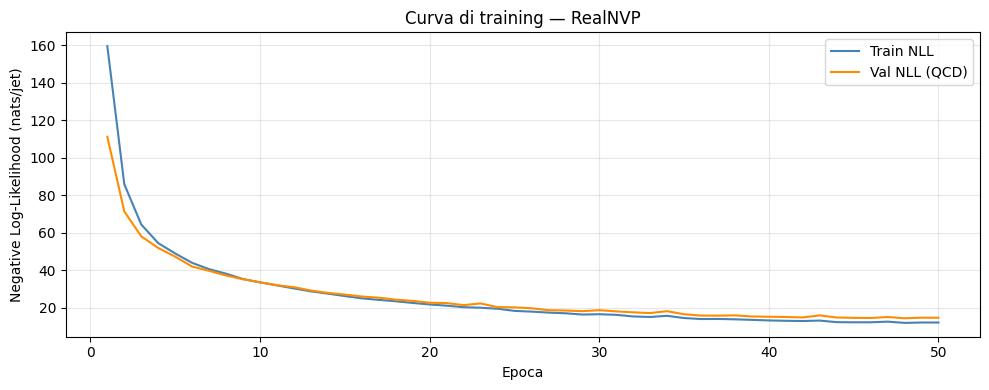

Salvato: nf_training_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs = range(1, len(history['train_nll']) + 1)
ax.plot(epochs, history['train_nll'], label='Train NLL', color='steelblue')
ax.plot(epochs, history['val_nll'],   label='Val NLL (QCD)', color='darkorange')
ax.set_xlabel('Epoca')
ax.set_ylabel('Negative Log-Likelihood (nats/jet)')
ax.set_title('Curva di training — RealNVP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nf_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: nf_training_curve.png')

#

## 5. Calcolo degli Anomaly Score

L'anomaly score è $-\log p_{\text{QCD}}(x)$.
Jet EJ dovrebbero avere score più alto (minore likelihood sotto il modello QCD).

In [12]:
@torch.no_grad()
def compute_scores(X_tensor, batch_size=1024):
    """Calcola -log p(x) per tutti i jet in X_tensor."""
    model.eval()
    scores = []
    for i in range(0, X_tensor.shape[0], batch_size):
        batch = X_tensor[i:i+batch_size].to(device)
        lp    = model.log_prob(batch)     # (B,)
        scores.append(-lp.cpu().numpy())
    return np.concatenate(scores)

print('Calcolo anomaly score sul val set...')
scores_val  = compute_scores(X_val_t)
print(f'  Score val:  min={scores_val.min():.2f}, max={scores_val.max():.2f}, '
      f'mean={scores_val.mean():.2f}±{scores_val.std():.2f}')

print('Calcolo anomaly score sul test set...')
scores_test = compute_scores(X_test_t)
print(f'  Score test: min={scores_test.min():.2f}, max={scores_test.max():.2f}, '
      f'mean={scores_test.mean():.2f}±{scores_test.std():.2f}')

Calcolo anomaly score sul val set...
  Score val:  min=-41.06, max=24433.42, mean=67.44±156.32
Calcolo anomaly score sul test set...
  Score test: min=-41.96, max=2657.47, mean=66.75±73.79


## 6. Distribuzione degli Anomaly Score

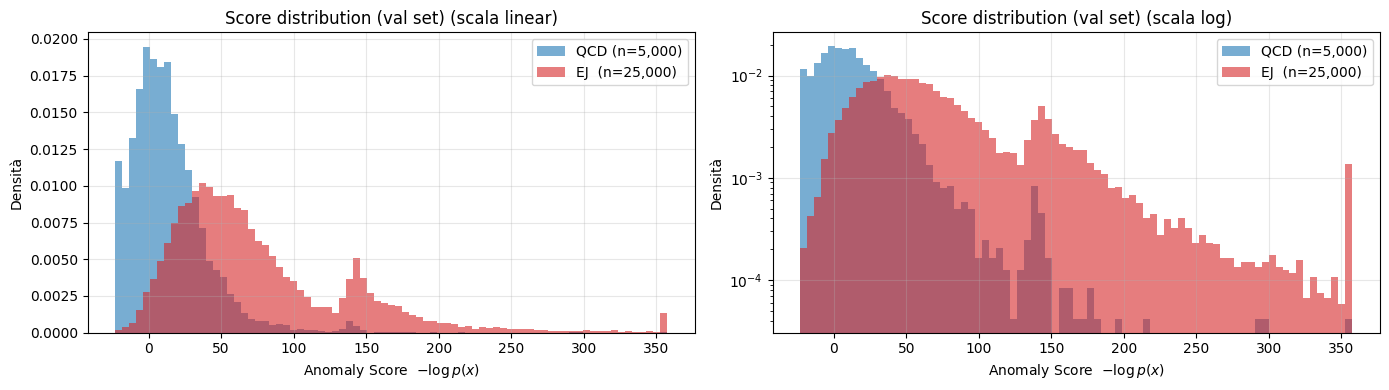

Salvato: nf_score_dist_val.png
  QCD: mean=14.25, std=28.28
  EJ:  mean=78.08, std=168.77


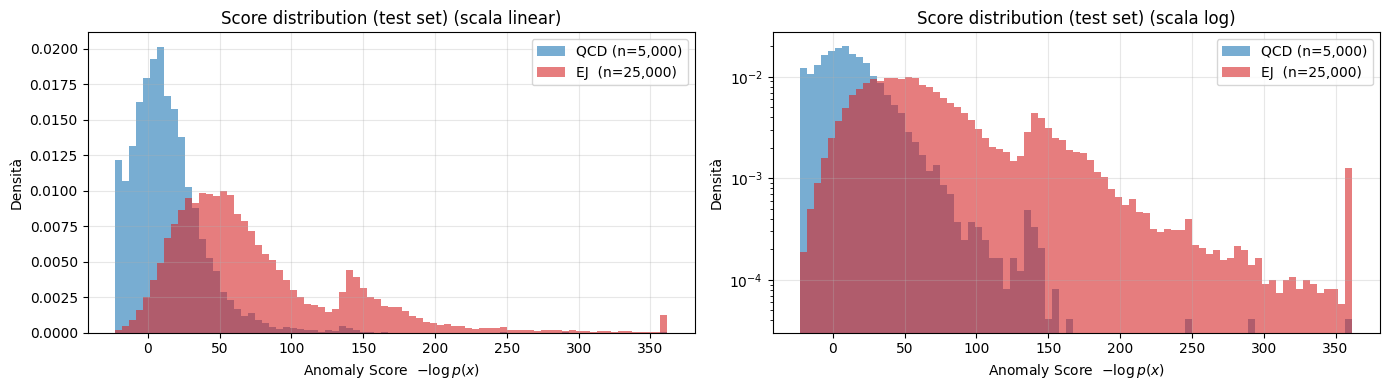

Salvato: nf_score_dist_test.png
  QCD: mean=13.78, std=26.65
  EJ:  mean=77.34, std=75.63


In [13]:
COLOR_QCD = '#1f77b4'
COLOR_EJ  = '#d62728'

def plot_score_distributions(scores, labels, title, filename,
                              clip_pct=(0.5, 99.5)):
    """Istogrammi sovrapposti QCD vs EJ delle anomaly score."""
    s_qcd = scores[labels == 0]
    s_ej  = scores[labels == 1]

    lo = np.percentile(scores, clip_pct[0])
    hi = np.percentile(scores, clip_pct[1])
    bins = np.linspace(lo, hi, 80)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, yscale in zip(axes, ['linear', 'log']):
        ax.hist(np.clip(s_qcd, lo, hi), bins=bins, density=True,
                alpha=0.6, color=COLOR_QCD, label=f'QCD (n={len(s_qcd):,})')
        ax.hist(np.clip(s_ej,  lo, hi), bins=bins, density=True,
                alpha=0.6, color=COLOR_EJ,  label=f'EJ  (n={len(s_ej):,})')
        ax.set_xlabel('Anomaly Score  $-\\log p(x)$')
        ax.set_ylabel('Densità')
        ax.set_yscale(yscale)
        ax.set_title(f'{title} (scala {yscale})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvato: {filename}')
    print(f'  QCD: mean={s_qcd.mean():.2f}, std={s_qcd.std():.2f}')
    print(f'  EJ:  mean={s_ej.mean():.2f}, std={s_ej.std():.2f}')


plot_score_distributions(scores_val, y_val,
                         title='Score distribution (val set)',
                         filename='nf_score_dist_val.png')

plot_score_distributions(scores_test, y_test,
                         title='Score distribution (test set)',
                         filename='nf_score_dist_test.png')

## 7. ROC Curve e AUC

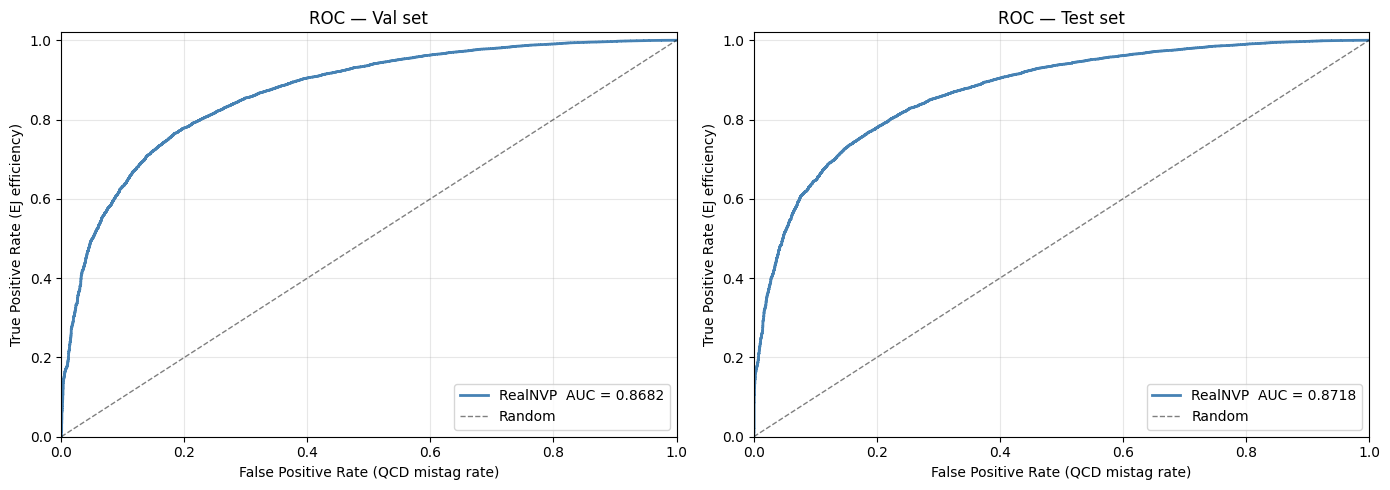

AUC val:  0.8682
AUC test: 0.8718


In [14]:
from sklearn.metrics import roc_auc_score

def compute_and_plot_roc(scores, labels, title, ax, color='steelblue'):
    """ROC curve (EJ = positivo, QCD = negativo)."""
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'RealNVP  AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate (QCD mistag rate)')
    ax.set_ylabel('True Positive Rate (EJ efficiency)')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    return roc_auc, fpr, tpr, thresholds


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

auc_val,  fpr_val,  tpr_val,  thr_val  = compute_and_plot_roc(
    scores_val,  y_val,  'ROC — Val set',  axes[0])

auc_test, fpr_test, tpr_test, thr_test = compute_and_plot_roc(
    scores_test, y_test, 'ROC — Test set', axes[1])

plt.tight_layout()
plt.savefig(OUT_DIR / 'nf_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC val:  {auc_val:.4f}')
print(f'AUC test: {auc_test:.4f}')

### 7.1 Efficiency vs Mistag Rate (curva 1/FPR vs TPR)

Nel contesto HEP è convenzione mostrare la **EJ efficiency** (TPR) in funzione del **QCD rejection** ($1/\text{FPR}$), in scala log-log.

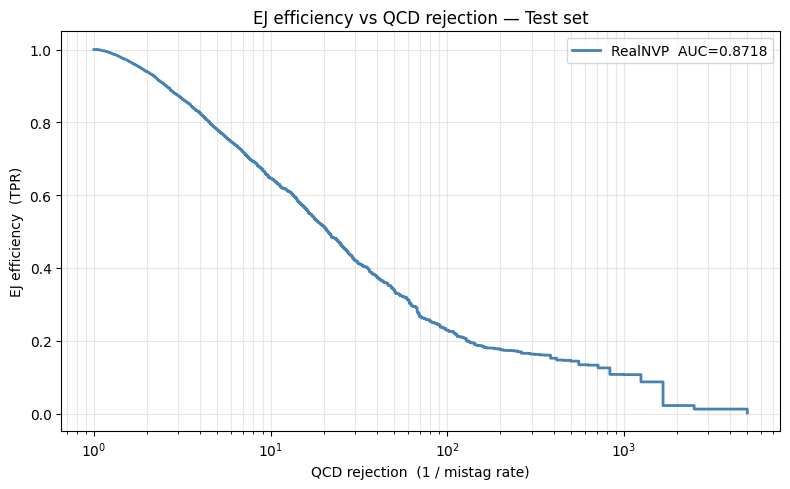

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

# Filtra FPR > 0 per evitare divisione per zero
mask_nz = fpr_test > 0
ax.plot(1.0 / fpr_test[mask_nz], tpr_test[mask_nz],
        color='steelblue', lw=2, label=f'RealNVP  AUC={auc_test:.4f}')

ax.set_xscale('log')
ax.set_xlabel('QCD rejection  (1 / mistag rate)')
ax.set_ylabel('EJ efficiency  (TPR)')
ax.set_title('EJ efficiency vs QCD rejection — Test set')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nf_efficiency_vs_rejection.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Salvataggio del modello

In [16]:
model_path = OUT_DIR / 'realnvp_model.pt'
torch.save({
    'model_state_dict' : model.state_dict(),
    'hyperparams': {
        'input_dim' : INPUT_DIM,
        'n_coupling': N_COUPLING,
        'hidden_dim': HIDDEN_DIM,
        'n_hidden'  : N_HIDDEN,
    },
    'auc_val'  : auc_val,
    'auc_test' : auc_test,
    'history'  : history,
}, model_path)
print(f'Modello salvato: {model_path}')

Modello salvato: C:\Users\delco\Desktop\Universita\Ad_M\nf_results\realnvp_model.pt


## 9. Analisi dello Spazio Latente

Visualizziamo la distribuzione dei vettori latenti $z = f(x)$ proiettati in 2D con PCA.
Se il flow ha funzionato, i QCD dovrebbero formare una gaussiana isotropa, mentre gli EJ
dovrebbero essere più dispersi o in regioni a bassa densità.

In [17]:
from sklearn.decomposition import PCA

@torch.no_grad()
def get_latent(X_tensor, batch_size=1024):
    """Ottiene la rappresentazione latente z = f(x)."""
    model.eval()
    zs = []
    for i in range(0, X_tensor.shape[0], batch_size):
        batch = X_tensor[i:i+batch_size].to(device)
        z = batch
        for layer in model.layers:
            z, _ = layer(z)
        zs.append(z.cpu().numpy())
    return np.concatenate(zs)

print('Calcolo vettori latenti (test set)...')
Z_test = get_latent(X_test_t)
print(f'  Shape: {Z_test.shape}')

# PCA 2D
pca = PCA(n_components=2, random_state=SEED)
Z2d = pca.fit_transform(Z_test)

var_ratio = pca.explained_variance_ratio_
print(f'  Varianza spiegata dalle prime 2 PC: {var_ratio.sum()*100:.1f}%')

Calcolo vettori latenti (test set)...
  Shape: (30000, 85)
  Varianza spiegata dalle prime 2 PC: 9.6%


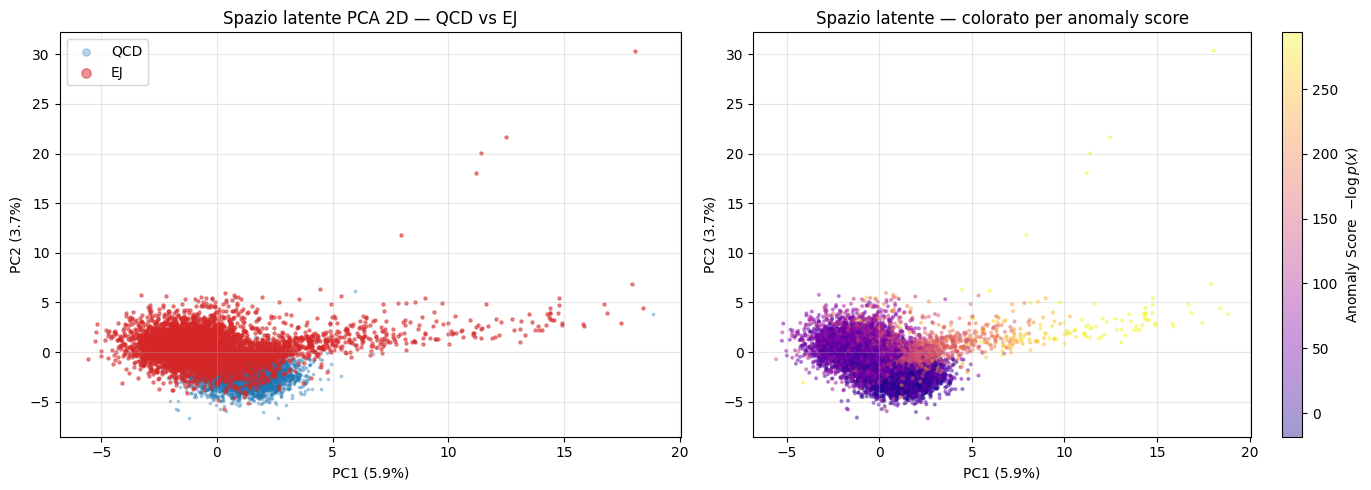

Salvato: nf_latent_space.png


In [18]:
# Plot: scatter colored by label + anomaly score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: QCD vs EJ ────────────────────────────────────────────────────────
ax = axes[0]
qcd_mask = y_test == 0
ej_mask  = y_test == 1

# Sottocampiona per leggibilità
N_PLOT = 5000
rng = np.random.default_rng(0)
idx_qcd = rng.choice(np.where(qcd_mask)[0], size=min(N_PLOT, qcd_mask.sum()), replace=False)
idx_ej  = rng.choice(np.where(ej_mask)[0],  size=min(N_PLOT, ej_mask.sum()),  replace=False)

ax.scatter(Z2d[idx_qcd, 0], Z2d[idx_qcd, 1], s=3, alpha=0.3,
           c=COLOR_QCD, label='QCD')
ax.scatter(Z2d[idx_ej,  0], Z2d[idx_ej,  1], s=5, alpha=0.5,
           c=COLOR_EJ,  label='EJ')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
ax.set_title('Spazio latente PCA 2D — QCD vs EJ')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)

# ── Plot 2: colorato per anomaly score ──────────────────────────────────────
ax = axes[1]
idx_all  = np.concatenate([idx_qcd, idx_ej])
sc_plot  = np.clip(scores_test[idx_all],
                   *np.percentile(scores_test, [1, 99]))
sc = ax.scatter(Z2d[idx_all, 0], Z2d[idx_all, 1],
                c=sc_plot, cmap='plasma', s=4, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Anomaly Score  $-\\log p(x)$')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
ax.set_title('Spazio latente — colorato per anomaly score')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'nf_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: nf_latent_space.png')

## 10. Riepilogo e soglie operative

In [19]:
print('═' * 55)
print('  RIEPILOGO RealNVP — Anomaly Detection EJ')
print('═' * 55)
print(f'  Architettura : RealNVP')
print(f'  Coupling lay.: {N_COUPLING}')
print(f'  Hidden dim   : {HIDDEN_DIM}')
print(f'  Parametri    : {n_params:,}')
print(f'  Input        : embedding fisso 86-dim (QCD only in train)')
print()
print(f'  AUC val  : {auc_val:.4f}')
print(f'  AUC test : {auc_test:.4f}')
print()

# Soglie operative a FPR fisso
for target_fpr in [0.01, 0.05, 0.10]:
    idx = np.searchsorted(fpr_test, target_fpr)
    if idx < len(tpr_test):
        print(f'  FPR ≤ {target_fpr*100:.0f}%  →  EJ efficiency = {tpr_test[idx]*100:.1f}%  '
              f'(threshold = {thr_test[idx]:.2f})')

print()
print(f'  Output salvati in: {OUT_DIR}')
print('═' * 55)

═══════════════════════════════════════════════════════
  RIEPILOGO RealNVP — Anomaly Detection EJ
═══════════════════════════════════════════════════════
  Architettura : RealNVP
  Coupling lay.: 8
  Hidden dim   : 256
  Parametri    : 800,076
  Input        : embedding fisso 86-dim (QCD only in train)

  AUC val  : 0.8682
  AUC test : 0.8718

  FPR ≤ 1%  →  EJ efficiency = 22.9%  (threshold = 108.56)
  FPR ≤ 5%  →  EJ efficiency = 51.4%  (threshold = 57.50)
  FPR ≤ 10%  →  EJ efficiency = 64.7%  (threshold = 43.92)

  Output salvati in: C:\Users\delco\Desktop\Universita\Ad_M\nf_results
═══════════════════════════════════════════════════════
